# 🌴 CPO (Crude Palm Oil) Price Prediction — LSTM Deep Learning
**Data Scientist Workflow | End-to-End Time Series Forecasting**

---
**Pipeline Overview:**
1. 📥 Data Loading & Exploration
2. 🔍 Exploratory Data Analysis (EDA)
3. 🧹 Preprocessing & Outlier Detection
4. 📊 Feature Engineering
5. ⚙️ Model Configuration (Tunable Parameters)
6. 🧠 LSTM Model Training
7. 📈 Evaluation & Diagnostics
8. 🔮 7-Day Price Forecast
---

## ⚙️ Cell 0 — Install & Import Dependencies

In [1]:
# ── Install (Colab may already have most of these) ──────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn torch

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from google.colab import files

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
print(f'✅ PyTorch version: {torch.__version__}')
print(f'✅ All libraries loaded successfully!')

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.labelcolor': '#e0e0e0',
    'axes.edgecolor': '#444',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2e3147',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 11
})
PALETTE = {'primary': '#00d4ff', 'secondary': '#ff6b6b', 'accent': '#ffd166',
           'green': '#06d6a0', 'purple': '#a855f7'}

✅ Device: cuda
✅ PyTorch version: 2.10.0+cu128
✅ All libraries loaded successfully!


---
## 🎛️ MASTER PARAMETER PANEL
> **Ubah semua hyperparameter di sini sebelum menjalankan pipeline**

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║               🎛️  MASTER PARAMETER CONFIGURATION PANEL                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

CONFIG = {
    # ── Data ────────────────────────────────────────────────────────────────
    'target_col'        : 'Close',        # Kolom target prediksi
    'feature_cols'      : ['Open', 'High', 'Low', 'Close', 'Pct_Change',
                           'MA_7', 'MA_21', 'EMA_12', 'EMA_26', 'MACD',
                           'RSI', 'Bollinger_Upper', 'Bollinger_Lower',
                           'Volatility_7', 'Momentum_5'],  # Semua fitur
    'train_split'       : 0.80,           # 80% train, 20% test
    'val_split'         : 0.10,           # 10% dari train → validation
    'scaler_type'       : 'MinMax',       # 'MinMax' atau 'Robust'

    # ── Sequence ─────────────────────────────────────────────────────────────
    'sequence_length'   : 60,             # Lookback window (hari)
    'forecast_horizon'  : 7,              # Prediksi ke depan (hari)

    # ── Model Architecture ───────────────────────────────────────────────────
    'lstm_hidden_size'  : 128,            # Neuron per layer LSTM
    'lstm_num_layers'   : 3,              # Jumlah layer LSTM (stacked)
    'dropout_rate'      : 0.3,            # Dropout antar layer
    'bidirectional'     : False,          # True → BiLSTM (lebih berat)
    'use_attention'     : True,           # True → tambah attention mechanism

    # ── Training ─────────────────────────────────────────────────────────────
    'epochs'            : 100,            # Epoch maksimal
    'batch_size'        : 32,             # Batch size
    'learning_rate'     : 0.001,          # Learning rate awal
    'optimizer'         : 'Adam',         # 'Adam', 'AdamW', 'SGD'
    'loss_function'     : 'MSE',          # 'MSE', 'MAE', 'Huber'
    'weight_decay'      : 1e-5,           # L2 regularization
    'gradient_clip'     : 1.0,            # Gradient clipping max norm

    # ── Learning Rate Scheduler ──────────────────────────────────────────────
    'scheduler_type'    : 'CosineAnnealing',  # 'StepLR', 'ReduceLROnPlateau', 'CosineAnnealing'
    'lr_step_size'      : 20,             # Untuk StepLR
    'lr_gamma'          : 0.5,            # Faktor reduksi LR
    'lr_patience'       : 10,             # Untuk ReduceLROnPlateau
    'lr_t_max'          : 50,             # Untuk CosineAnnealing

    # ── Early Stopping ───────────────────────────────────────────────────────
    'early_stopping'    : True,           # Aktifkan early stopping
    'patience'          : 15,             # Epoch toleransi tanpa improvement
    'min_delta'         : 1e-6,           # Minimum improvement threshold

    # ── Outlier Handling ─────────────────────────────────────────────────────
    'outlier_method'    : 'IQR',          # 'IQR', 'ZScore', 'None'
    'iqr_factor'        : 3.0,            # Faktor IQR (lebih besar = lebih toleran)
    'zscore_threshold'  : 3.5,            # Z-score threshold

    # ── Misc ─────────────────────────────────────────────────────────────────
    'seed'              : 42,
    'save_model'        : True,           # Simpan model .pth
}

print('╔══════════════════════════════════════════════════════╗')
print('║          ACTIVE CONFIGURATION SUMMARY                ║')
print('╚══════════════════════════════════════════════════════╝')
for k, v in CONFIG.items():
    print(f'  {k:<25} : {v}')

╔══════════════════════════════════════════════════════╗
║          ACTIVE CONFIGURATION SUMMARY                ║
╚══════════════════════════════════════════════════════╝
  target_col                : Close
  feature_cols              : ['Open', 'High', 'Low', 'Close', 'Pct_Change', 'MA_7', 'MA_21', 'EMA_12', 'EMA_26', 'MACD', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower', 'Volatility_7', 'Momentum_5']
  train_split               : 0.8
  val_split                 : 0.1
  scaler_type               : MinMax
  sequence_length           : 60
  forecast_horizon          : 7
  lstm_hidden_size          : 128
  lstm_num_layers           : 3
  dropout_rate              : 0.3
  bidirectional             : False
  use_attention             : True
  epochs                    : 100
  batch_size                : 32
  learning_rate             : 0.001
  optimizer                 : Adam
  loss_function             : MSE
  weight_decay              : 1e-05
  gradient_clip             : 1.0
  scheduler_t

---
## 📥 Step 1 — Data Loading & Initial Exploration

In [3]:
# ── Upload CSV ───────────────────────────────────────────────────────────────
print('📁 Upload file CSV dataset CPO...')
uploaded = files.upload()
csv_path = list(uploaded.keys())[0]
print(f'✅ File uploaded: {csv_path}')

📁 Upload file CSV dataset CPO...


Saving Data Historis Minyak Sawit AS Berjangka.csv to Data Historis Minyak Sawit AS Berjangka.csv
✅ File uploaded: Data Historis Minyak Sawit AS Berjangka.csv


In [4]:
# ── Parse Indonesian number format ──────────────────────────────────────────
def parse_indonesian_number(series: pd.Series) -> pd.Series:
    """Convert '1.135,75' → 1135.75 (Indonesian locale format)."""
    return (
        series.astype(str)
        .str.replace('.', '', regex=False)   # Remove thousands separator
        .str.replace(',', '.', regex=False)  # Replace decimal comma
        .str.replace('%', '', regex=False)   # Remove percent sign
        .pipe(pd.to_numeric, errors='coerce')
    )

# ── Load raw data ────────────────────────────────────────────────────────────
raw = pd.read_csv(csv_path)

# Rename to standard English column names
raw.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Pct_Change']

# Parse date (Indonesian DD/MM/YYYY format)
raw['Date'] = pd.to_datetime(raw['Date'], format='%d/%m/%Y', dayfirst=True)

# Parse numeric columns
for col in ['Close', 'Open', 'High', 'Low', 'Pct_Change']:
    raw[col] = parse_indonesian_number(raw[col])

# Sort chronologically (oldest → newest)
raw = raw.sort_values('Date').reset_index(drop=True)
raw.drop(columns=['Volume'], inplace=True)  # All null → drop

print(f'📊 Dataset Shape   : {raw.shape}')
print(f'📅 Date Range      : {raw["Date"].min().date()} → {raw["Date"].max().date()}')
print(f'💰 Close Price Range: {raw["Close"].min():.2f} — {raw["Close"].max():.2f}')
print(f'\n🔍 Sample (first 5 rows):')
display(raw.head())
print(f'\n🔍 Sample (last 5 rows):')
display(raw.tail())
print(f'\n📋 Data Types & Null Check:')
display(raw.info())

📊 Dataset Shape   : (2804, 6)
📅 Date Range      : 2014-08-18 → 2026-04-28
💰 Close Price Range: 419.25 — 1947.00

🔍 Sample (first 5 rows):


,Date,Close,Open,High,Low,Pct_Change
0,2014-08-18,665.00,665.00,665.00,665.00,-3.69
1,2014-08-19,657.00,657.00,657.00,657.00,-1.20
2,2014-08-20,648.75,648.75,648.75,648.75,-1.26
3,2014-08-21,648.00,648.00,648.00,648.00,-0.12
4,2014-08-22,639.50,639.50,639.50,639.50,-1.31



🔍 Sample (last 5 rows):


,Date,Close,Open,High,Low,Pct_Change
2799,2026-04-21,1150.50,1150.50,1150.50,1150.50,1.30
2800,2026-04-22,1136.25,1136.25,1136.25,1136.25,-1.24
2801,2026-04-23,1139.75,1139.75,1139.75,1139.75,0.31
2802,2026-04-27,1130.75,1129.75,1130.75,1129.75,-0.79
2803,2026-04-28,1140.25,1140.25,1140.25,1140.25,0.84



📋 Data Types & Null Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2804 entries, 0 to 2803
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2804 non-null   datetime64[ns]
 1   Close       2804 non-null   float64       
 2   Open        2804 non-null   float64       
 3   High        2804 non-null   float64       
 4   Low         2804 non-null   float64       
 5   Pct_Change  2804 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 131.6 KB


None

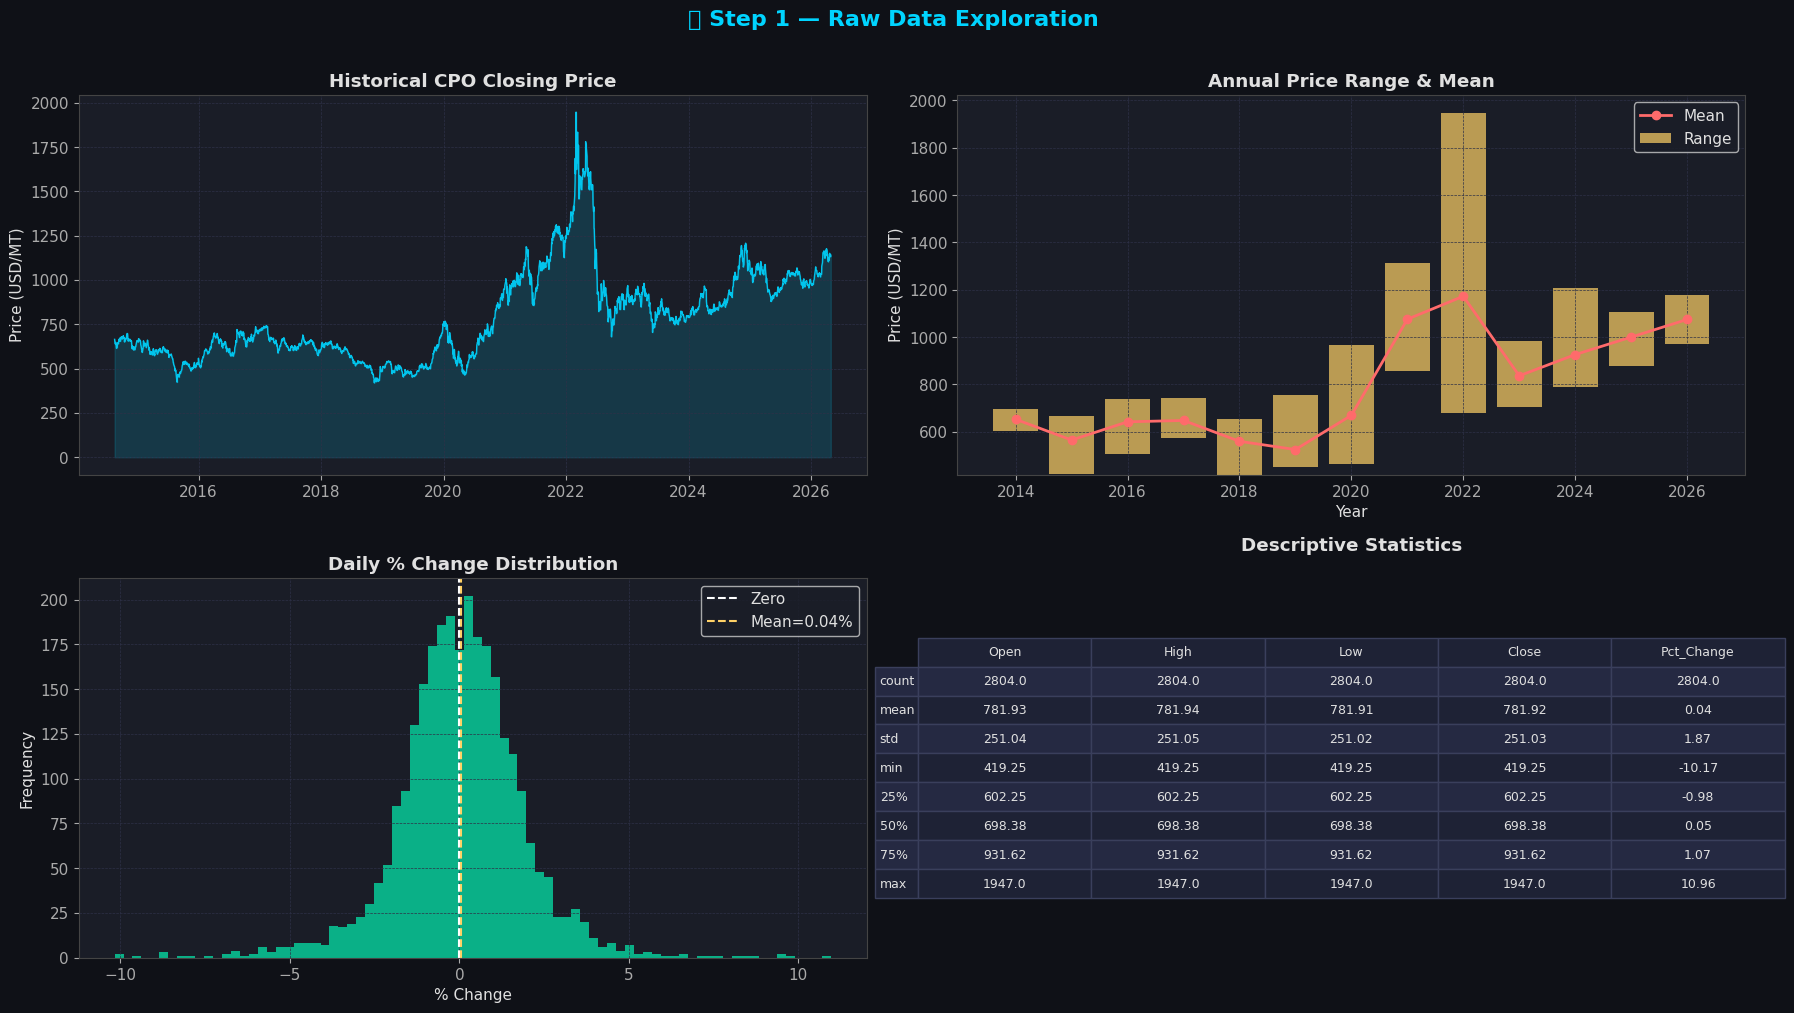

✅ Step 1 complete.


In [5]:
# ── Visualization 1: Raw Price History ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('📥 Step 1 — Raw Data Exploration', fontsize=16,
             fontweight='bold', color=PALETTE['primary'], y=1.01)

# 1a. Full price history
ax = axes[0, 0]
ax.plot(raw['Date'], raw['Close'], color=PALETTE['primary'], lw=1, alpha=0.9)
ax.fill_between(raw['Date'], raw['Close'], alpha=0.15, color=PALETTE['primary'])
ax.set_title('Historical CPO Closing Price', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True)

# 1b. OHLC spread per year
ax = axes[0, 1]
raw['Year'] = raw['Date'].dt.year
yearly = raw.groupby('Year')['Close'].agg(['mean', 'min', 'max'])
ax.bar(yearly.index, yearly['max'] - yearly['min'],
       bottom=yearly['min'], color=PALETTE['accent'], alpha=0.7, label='Range')
ax.plot(yearly.index, yearly['mean'], 'o-', color=PALETTE['secondary'],
        lw=2, label='Mean', markersize=6)
ax.set_title('Annual Price Range & Mean', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True)

# 1c. Daily % change distribution
ax = axes[1, 0]
ax.hist(raw['Pct_Change'].dropna(), bins=80, color=PALETTE['green'],
        alpha=0.8, edgecolor='none')
ax.axvline(0, color='white', ls='--', lw=1.5, label='Zero')
ax.axvline(raw['Pct_Change'].mean(), color=PALETTE['accent'],
           ls='--', lw=1.5, label=f'Mean={raw["Pct_Change"].mean():.2f}%')
ax.set_title('Daily % Change Distribution', fontweight='bold')
ax.set_xlabel('% Change')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True)

# 1d. Descriptive statistics table
ax = axes[1, 1]
ax.axis('off')
stats_df = raw[['Open', 'High', 'Low', 'Close', 'Pct_Change']].describe().round(2)
table = ax.table(cellText=stats_df.values,
                 rowLabels=stats_df.index,
                 colLabels=stats_df.columns,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#1e2235' if row % 2 == 0 else '#252942')
    cell.set_edgecolor('#3a3f5c')
    cell.set_text_props(color='#e0e0e0')
ax.set_title('Descriptive Statistics', fontweight='bold', pad=20)

raw.drop(columns=['Year'], inplace=True)
plt.tight_layout()
plt.savefig('step1_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Step 1 complete.')

---
## 🔍 Step 2 — Outlier Detection & Handling

In [6]:
def detect_outliers_iqr(series: pd.Series, factor: float = 3.0):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series < lower, series > upper, lower, upper

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.5):
    z = np.abs(stats.zscore(series.dropna()))
    mask = pd.Series(False, index=series.index)
    mask[series.dropna().index] = z > threshold
    return mask, -threshold, threshold

df = raw.copy()
method = CONFIG['outlier_method']

outlier_summary = {}
for col in ['Open', 'High', 'Low', 'Close']:
    if method == 'IQR':
        lo_mask, hi_mask, lb, ub = detect_outliers_iqr(df[col], CONFIG['iqr_factor'])
        outlier_mask = lo_mask | hi_mask
    elif method == 'ZScore':
        outlier_mask, lb, ub = detect_outliers_zscore(df[col], CONFIG['zscore_threshold'])
        lo_mask, hi_mask = outlier_mask, outlier_mask
    else:
        outlier_mask = pd.Series(False, index=df.index)
        lb, ub = df[col].min(), df[col].max()

    n_out = outlier_mask.sum()
    outlier_summary[col] = {'count': n_out, 'pct': n_out / len(df) * 100,
                            'lower_bound': round(lb, 2), 'upper_bound': round(ub, 2)}

    # Cap outliers with Winsorization (preserve timestamp continuity)
    if method != 'None':
        df[col] = df[col].clip(lower=lb, upper=ub)

print(f'🔍 Outlier Detection Method: {method}')
out_df = pd.DataFrame(outlier_summary).T
display(out_df)

🔍 Outlier Detection Method: IQR


,count,pct,lower_bound,upper_bound
Open,1.0,0.035663,-385.88,1919.75
High,1.0,0.035663,-385.88,1919.75
Low,1.0,0.035663,-385.88,1919.75
Close,1.0,0.035663,-385.88,1919.75


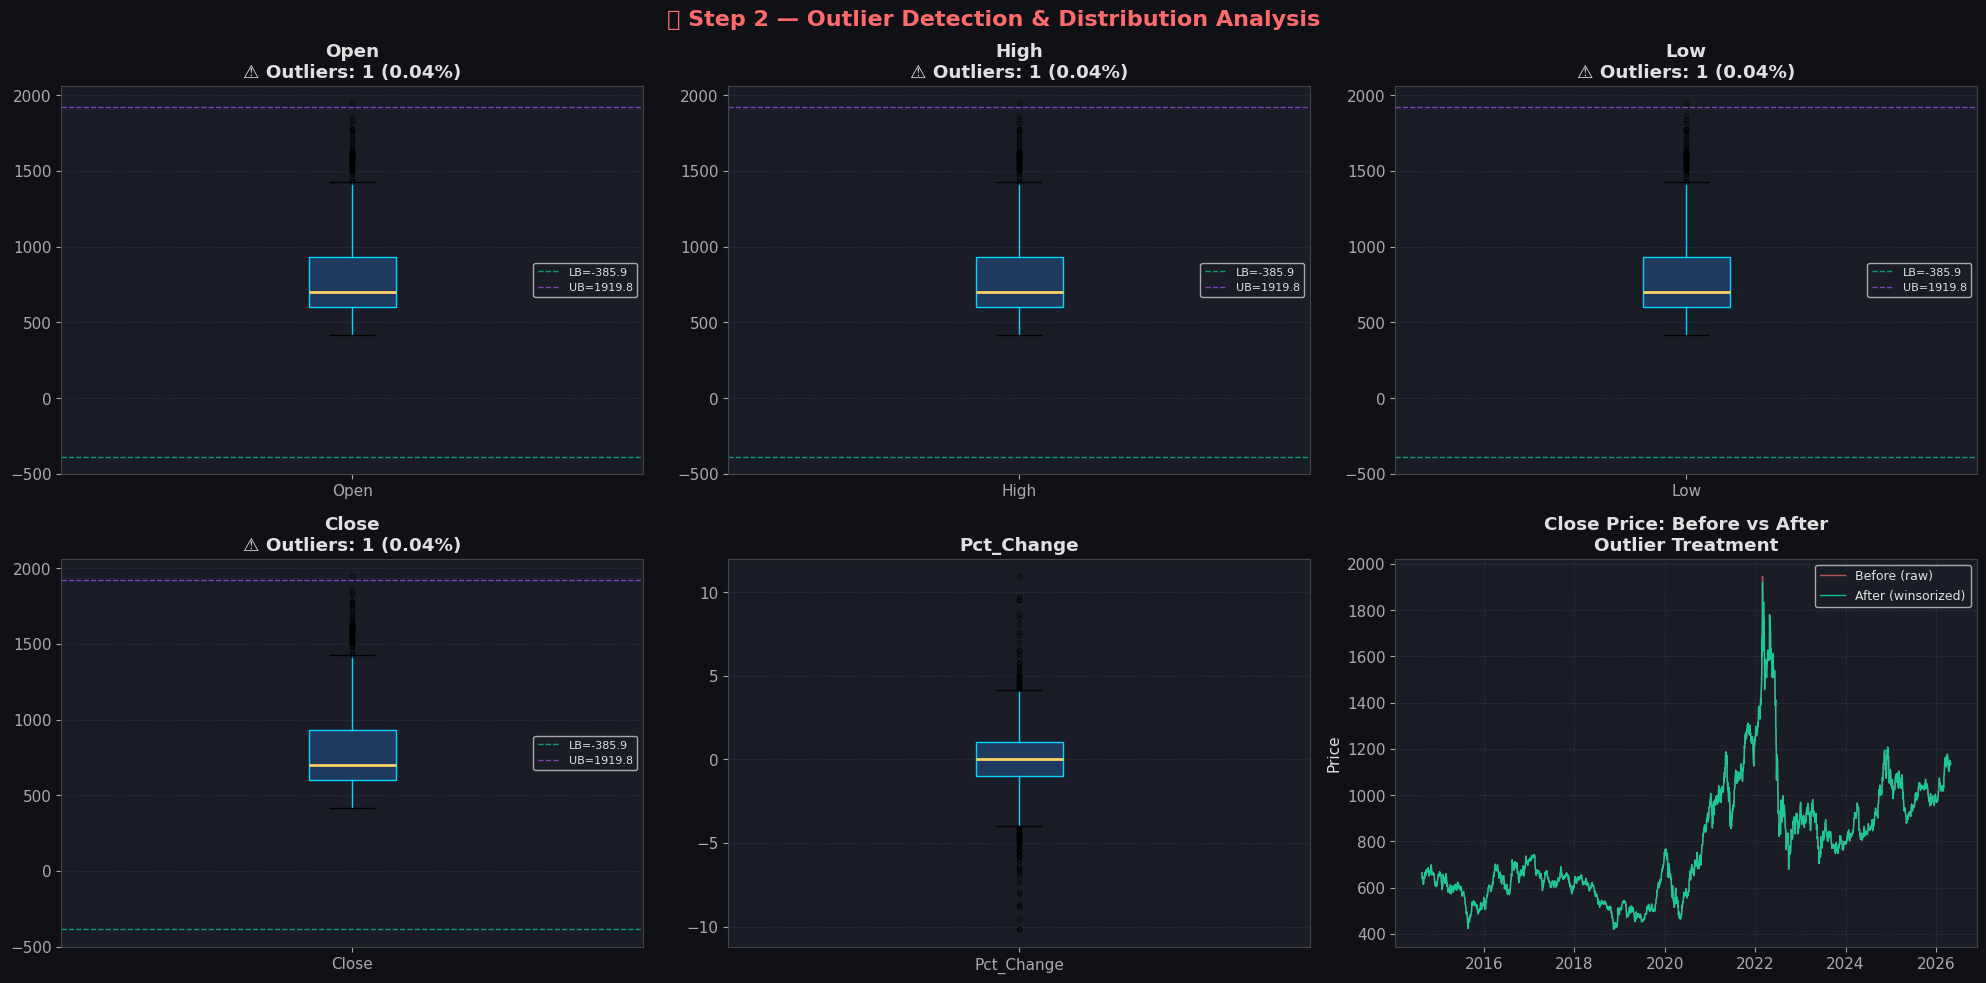

✅ Step 2 complete.


In [7]:
# ── Visualization 2: Outlier Analysis ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('🔍 Step 2 — Outlier Detection & Distribution Analysis',
             fontsize=16, fontweight='bold', color=PALETTE['secondary'])

for i, col in enumerate(['Open', 'High', 'Low', 'Close', 'Pct_Change']):
    row, c = divmod(i, 3)
    ax = axes[row, c]
    data = raw[col].dropna()

    # Boxplot
    bp = ax.boxplot(data.values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#1e3a5f', color=PALETTE['primary']),
                    whiskerprops=dict(color=PALETTE['primary']),
                    medianprops=dict(color=PALETTE['accent'], lw=2),
                    flierprops=dict(marker='o', color=PALETTE['secondary'],
                                   alpha=0.5, markersize=3))

    # IQR bounds annotation
    if col in outlier_summary:
        lb = outlier_summary[col]['lower_bound']
        ub = outlier_summary[col]['upper_bound']
        ax.axhline(lb, color=PALETTE['green'], ls='--', lw=1, alpha=0.7, label=f'LB={lb:.1f}')
        ax.axhline(ub, color=PALETTE['purple'], ls='--', lw=1, alpha=0.7, label=f'UB={ub:.1f}')
        n_out = outlier_summary[col]['count']
        pct = outlier_summary[col]['pct']
        ax.set_title(f'{col}\n⚠️ Outliers: {n_out} ({pct:.2f}%)', fontweight='bold')
        ax.legend(fontsize=8)
    else:
        ax.set_title(col, fontweight='bold')
    ax.set_xticklabels([col])
    ax.grid(True, axis='y')

# 6th panel: Before vs After comparison (Close)
ax = axes[1, 2]
ax.plot(raw['Date'], raw['Close'], color=PALETTE['secondary'], lw=1,
        alpha=0.7, label='Before (raw)')
ax.plot(df['Date'], df['Close'], color=PALETTE['green'], lw=1,
        alpha=0.9, label='After (winsorized)')
ax.set_title('Close Price: Before vs After\nOutlier Treatment', fontweight='bold')
ax.set_ylabel('Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('step2_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Step 2 complete.')

---
## 📊 Step 3 — Feature Engineering

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators as model features."""
    d = df.copy()

    # ── Moving Averages ─────────────────────────────────────────────────────
    d['MA_7']  = d['Close'].rolling(7).mean()
    d['MA_21'] = d['Close'].rolling(21).mean()
    d['MA_50'] = d['Close'].rolling(50).mean()

    # ── Exponential Moving Averages ──────────────────────────────────────────
    d['EMA_12'] = d['Close'].ewm(span=12, adjust=False).mean()
    d['EMA_26'] = d['Close'].ewm(span=26, adjust=False).mean()

    # ── MACD ────────────────────────────────────────────────────────────────
    d['MACD']        = d['EMA_12'] - d['EMA_26']
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    # ── RSI (14-period) ──────────────────────────────────────────────────────
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    d['RSI'] = 100 - (100 / (1 + rs))

    # ── Bollinger Bands (20-period, 2σ) ──────────────────────────────────────
    roll_mean = d['Close'].rolling(20).mean()
    roll_std  = d['Close'].rolling(20).std()
    d['Bollinger_Upper'] = roll_mean + 2 * roll_std
    d['Bollinger_Lower'] = roll_mean - 2 * roll_std
    d['BB_Width']        = d['Bollinger_Upper'] - d['Bollinger_Lower']

    # ── Volatility & Momentum ────────────────────────────────────────────────
    d['Volatility_7']  = d['Close'].rolling(7).std()
    d['Volatility_30'] = d['Close'].rolling(30).std()
    d['Momentum_5']    = d['Close'].diff(5)
    d['Momentum_14']   = d['Close'].diff(14)

    # ── Lag Features ────────────────────────────────────────────────────────
    for lag in [1, 3, 7]:
        d[f'Close_Lag_{lag}'] = d['Close'].shift(lag)

    # ── Price Ratios ─────────────────────────────────────────────────────────
    d['HL_Ratio'] = (d['High'] - d['Low']) / (d['Close'] + 1e-9)
    d['OC_Ratio'] = (d['Close'] - d['Open']) / (d['Open'] + 1e-9)

    # ── Calendar Features ────────────────────────────────────────────────────
    d['DayOfWeek'] = d['Date'].dt.dayofweek   # 0=Mon … 4=Fri
    d['Month']     = d['Date'].dt.month
    d['Quarter']   = d['Date'].dt.quarter

    # Update CONFIG feature list to include all generated features
    return d

df = engineer_features(df)

# Drop rows with NaN (from rolling windows)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Feature engineering complete.')
print(f'   Shape after feature engineering: {df.shape}')
print(f'   Features available: {list(df.columns)}')

✅ Feature engineering complete.
   Shape after feature engineering: (2755, 30)
   Features available: ['Date', 'Close', 'Open', 'High', 'Low', 'Pct_Change', 'MA_7', 'MA_21', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower', 'BB_Width', 'Volatility_7', 'Volatility_30', 'Momentum_5', 'Momentum_14', 'Close_Lag_1', 'Close_Lag_3', 'Close_Lag_7', 'HL_Ratio', 'OC_Ratio', 'DayOfWeek', 'Month', 'Quarter']


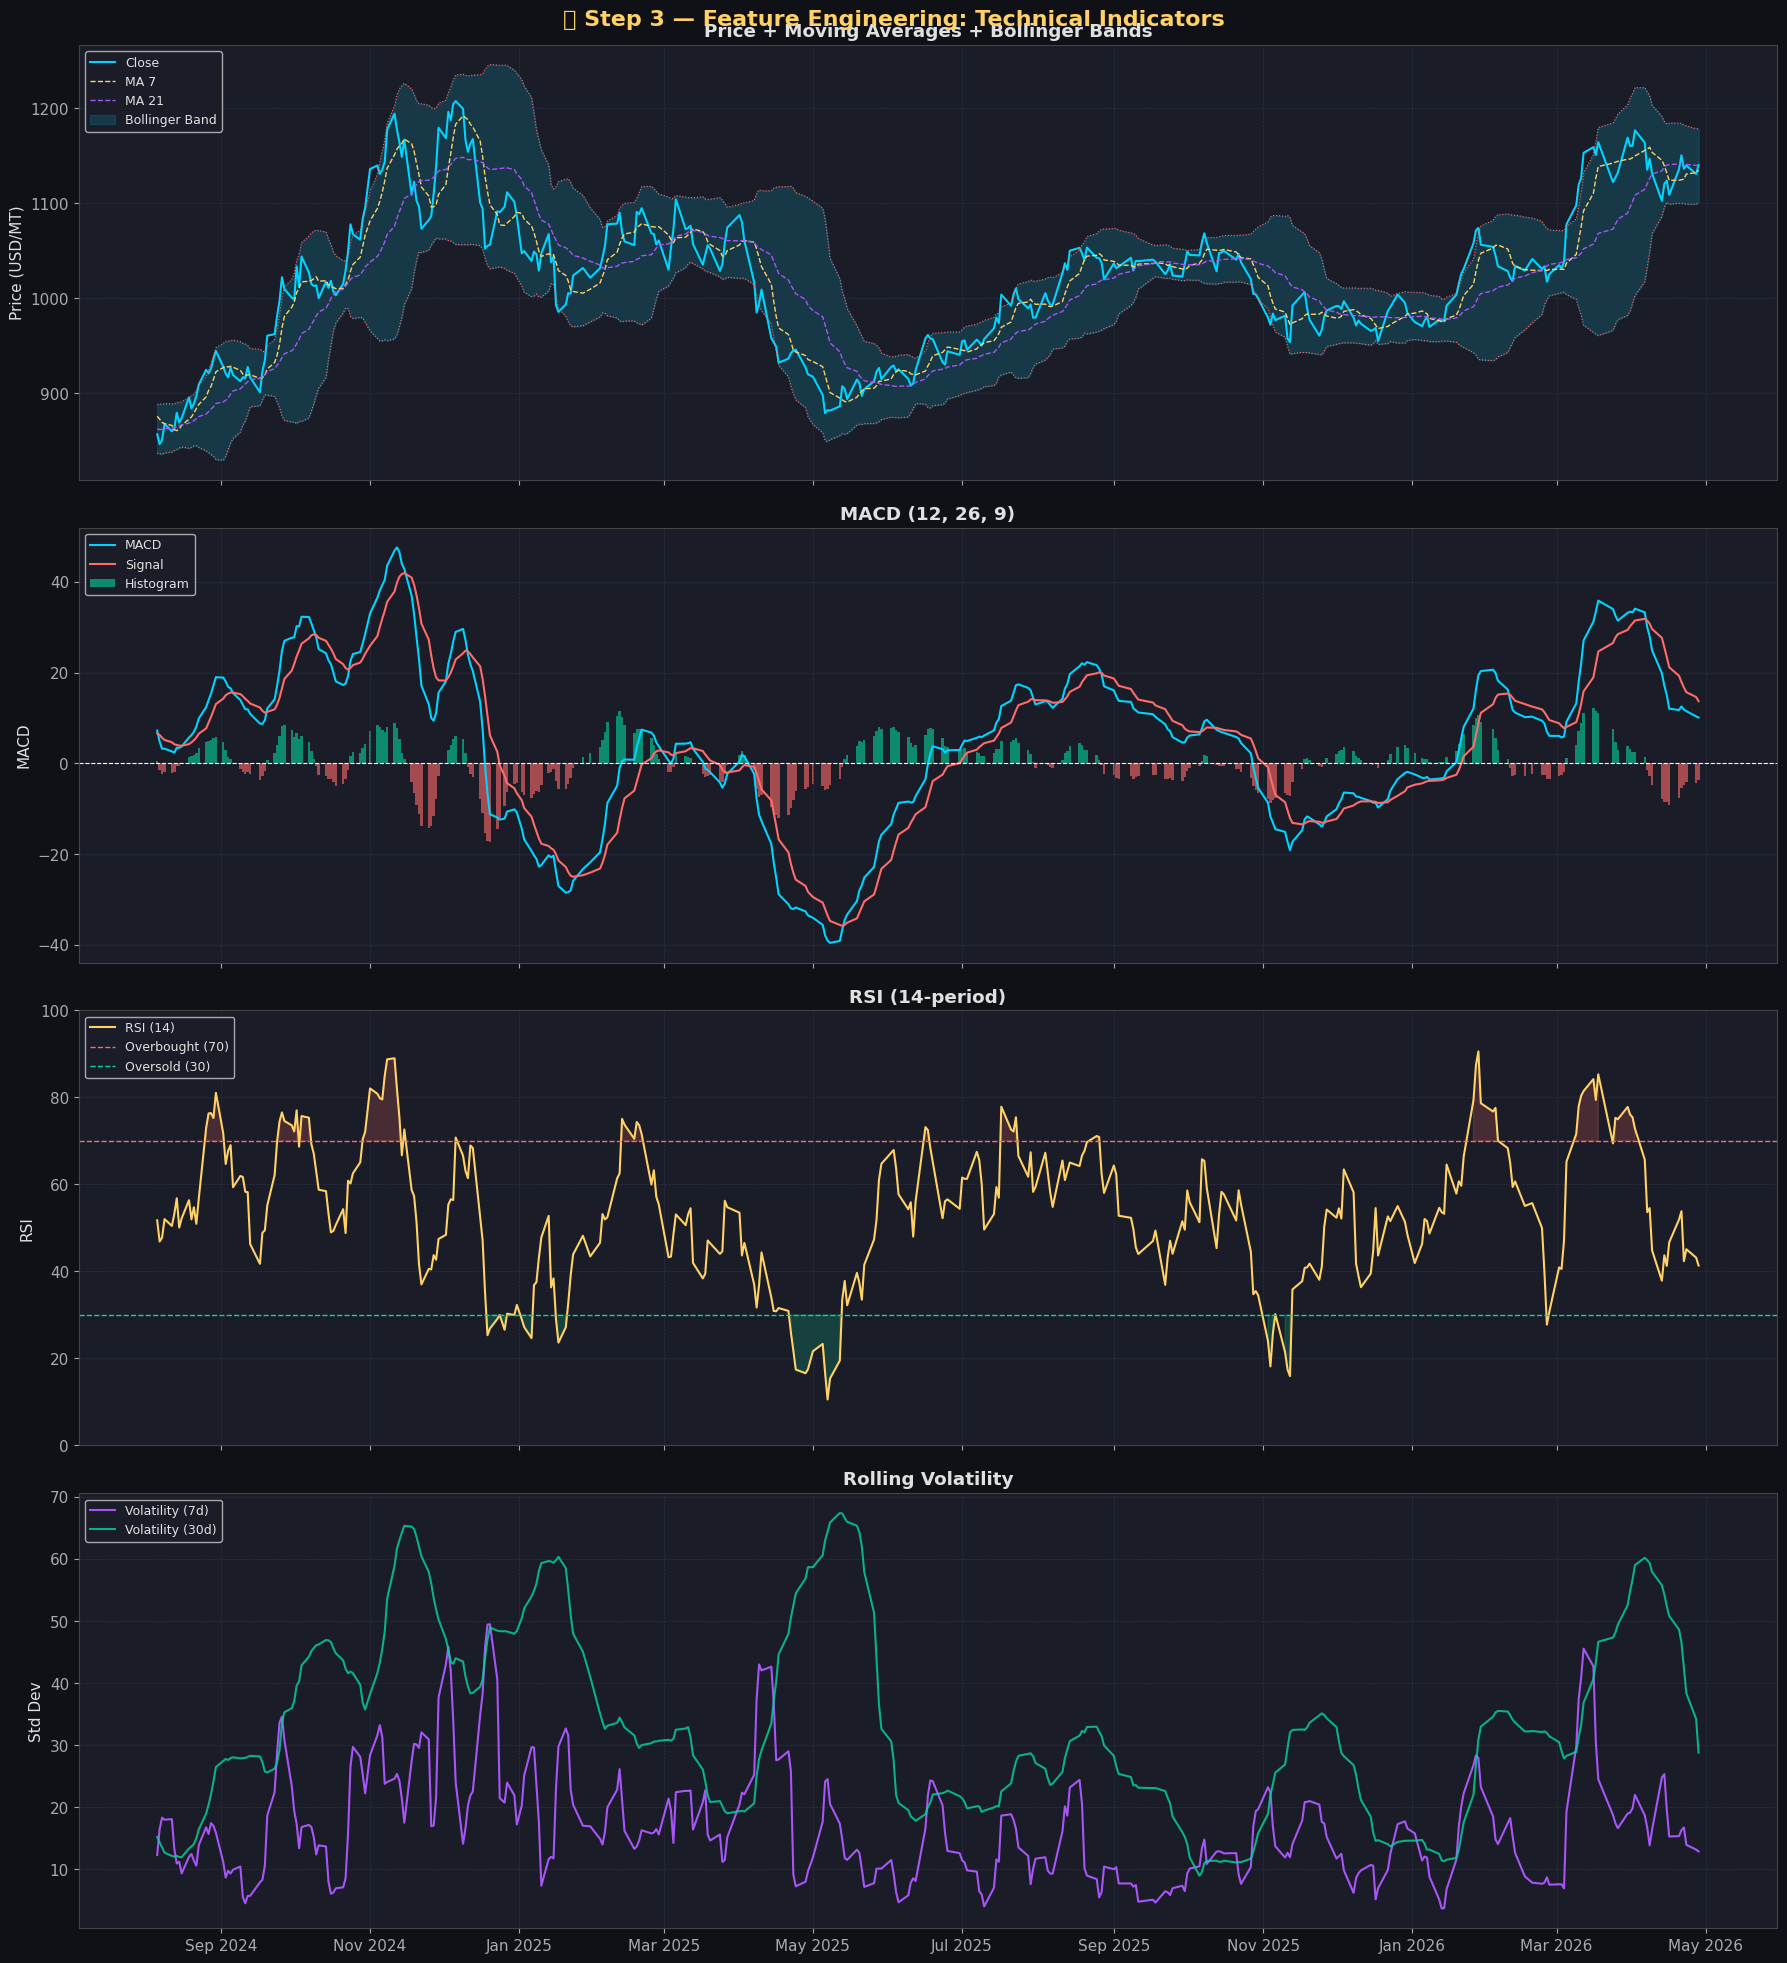

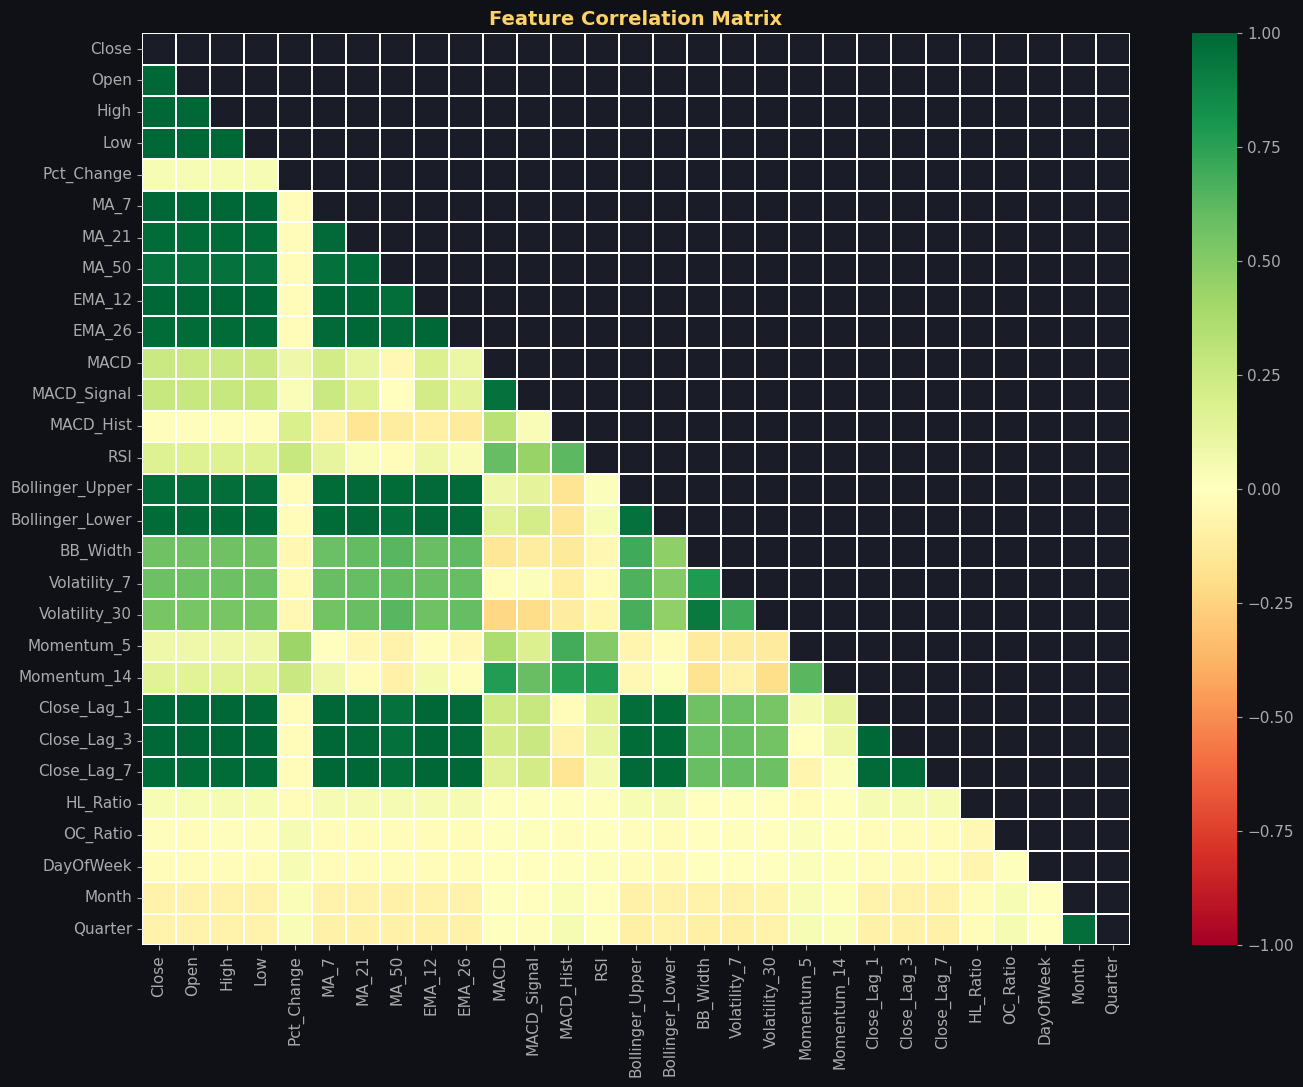

✅ Step 3 complete.


In [9]:
# ── Visualization 3: Technical Indicators ────────────────────────────────────
recent = df.tail(365).copy()  # Last year for clarity

fig, axes = plt.subplots(4, 1, figsize=(18, 20), sharex=True)
fig.suptitle('📊 Step 3 — Feature Engineering: Technical Indicators',
             fontsize=16, fontweight='bold', color=PALETTE['accent'])

# Panel 1: Price + Bollinger + MAs
ax = axes[0]
ax.plot(recent['Date'], recent['Close'], color=PALETTE['primary'], lw=1.5, label='Close')
ax.plot(recent['Date'], recent['MA_7'], color=PALETTE['accent'], lw=1, ls='--', label='MA 7')
ax.plot(recent['Date'], recent['MA_21'], color=PALETTE['purple'], lw=1, ls='--', label='MA 21')
ax.fill_between(recent['Date'], recent['Bollinger_Upper'], recent['Bollinger_Lower'],
                alpha=0.15, color=PALETTE['primary'], label='Bollinger Band')
ax.plot(recent['Date'], recent['Bollinger_Upper'], color=PALETTE['secondary'],
        lw=0.8, ls=':')
ax.plot(recent['Date'], recent['Bollinger_Lower'], color=PALETTE['secondary'],
        lw=0.8, ls=':')
ax.set_title('Price + Moving Averages + Bollinger Bands', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

# Panel 2: MACD
ax = axes[1]
ax.plot(recent['Date'], recent['MACD'], color=PALETTE['primary'], lw=1.5, label='MACD')
ax.plot(recent['Date'], recent['MACD_Signal'], color=PALETTE['secondary'],
        lw=1.5, label='Signal')
ax.bar(recent['Date'], recent['MACD_Hist'], color=np.where(
    recent['MACD_Hist'] >= 0, PALETTE['green'], PALETTE['secondary']),
    alpha=0.6, width=1, label='Histogram')
ax.axhline(0, color='white', ls='--', lw=0.8)
ax.set_title('MACD (12, 26, 9)', fontweight='bold')
ax.set_ylabel('MACD')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

# Panel 3: RSI
ax = axes[2]
ax.plot(recent['Date'], recent['RSI'], color=PALETTE['accent'], lw=1.5, label='RSI (14)')
ax.axhline(70, color=PALETTE['secondary'], ls='--', lw=1, label='Overbought (70)')
ax.axhline(30, color=PALETTE['green'], ls='--', lw=1, label='Oversold (30)')
ax.fill_between(recent['Date'], 70, recent['RSI'],
                where=recent['RSI'] > 70, alpha=0.2, color=PALETTE['secondary'])
ax.fill_between(recent['Date'], 30, recent['RSI'],
                where=recent['RSI'] < 30, alpha=0.2, color=PALETTE['green'])
ax.set_ylim(0, 100)
ax.set_title('RSI (14-period)', fontweight='bold')
ax.set_ylabel('RSI')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

# Panel 4: Volatility
ax = axes[3]
ax.plot(recent['Date'], recent['Volatility_7'], color=PALETTE['purple'],
        lw=1.5, label='Volatility (7d)')
ax.plot(recent['Date'], recent['Volatility_30'], color=PALETTE['green'],
        lw=1.5, label='Volatility (30d)', alpha=0.8)
ax.set_title('Rolling Volatility', fontweight='bold')
ax.set_ylabel('Std Dev')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('step3_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold',
             color=PALETTE['accent'])
plt.tight_layout()
plt.savefig('step3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Step 3 complete.')

---
## 🧹 Step 4 — Preprocessing: Scaling & Sequence Creation

In [10]:
# ── Select features based on CONFIG ──────────────────────────────────────────
# Use all available numeric features for maximum signal
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c != 'Close'] + ['Close']
feature_cols = [c for c in feature_cols if c in df.columns]
target_idx   = feature_cols.index('Close')

print(f'✅ Feature columns used ({len(feature_cols)}): {feature_cols}')
print(f'   Target column index: {target_idx} → "Close"')

data_array = df[feature_cols].values

# ── Train / Val / Test Split (temporal — no shuffle!) ────────────────────────
n = len(data_array)
train_end = int(n * CONFIG['train_split'])
val_end   = int(n * (CONFIG['train_split'] + CONFIG['val_split']))

train_data = data_array[:train_end]
val_data   = data_array[train_end:val_end]
test_data  = data_array[val_end:]

print(f'\n📊 Split Summary (temporal — no data leakage):')
print(f'   Train : {len(train_data):,} rows '
      f'({df["Date"].iloc[0].date()} → {df["Date"].iloc[train_end-1].date()})')
print(f'   Val   : {len(val_data):,} rows '
      f'({df["Date"].iloc[train_end].date()} → {df["Date"].iloc[val_end-1].date()})')
print(f'   Test  : {len(test_data):,} rows '
      f'({df["Date"].iloc[val_end].date()} → {df["Date"].iloc[-1].date()})')

# ── Scaling (fit on train ONLY to prevent leakage) ───────────────────────────
scaler_cls = MinMaxScaler if CONFIG['scaler_type'] == 'MinMax' else RobustScaler
scaler = scaler_cls()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

# Close-only scaler for inverse transform of predictions
close_scaler = scaler_cls()
close_scaler.fit(train_data[:, target_idx].reshape(-1, 1))

print(f'\n✅ Scaler: {CONFIG["scaler_type"]}Scaler fitted on train set only.')

# ── Sequence Builder ─────────────────────────────────────────────────────────
def build_sequences(scaled_data, seq_len: int, target_col_idx: int):
    """Build (X, y) pairs where y = next Close price."""
    X, y = [], []
    for i in range(len(scaled_data) - seq_len):
        X.append(scaled_data[i : i + seq_len, :])       # All features
        y.append(scaled_data[i + seq_len, target_col_idx])  # Target = Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

SEQ = CONFIG['sequence_length']

# For validation/test we need overlap with previous data to build context
X_train, y_train = build_sequences(train_scaled, SEQ, target_idx)

# Prepend tail of train to val/test for context continuity
val_with_context  = np.concatenate([train_scaled[-SEQ:], val_scaled], axis=0)
test_with_context = np.concatenate([val_scaled[-SEQ:], test_scaled], axis=0)

X_val,  y_val  = build_sequences(val_with_context,  SEQ, target_idx)
X_test, y_test = build_sequences(test_with_context, SEQ, target_idx)

print(f'\n✅ Sequence shape (SEQ_LEN={SEQ})')
print(f'   X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'   X_val  : {X_val.shape},  y_val  : {y_val.shape}')
print(f'   X_test : {X_test.shape}, y_test : {y_test.shape}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
def to_loader(X, y, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=DEVICE.type == 'cuda')

BS = CONFIG['batch_size']
train_loader = to_loader(X_train, y_train, BS, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   BS)
test_loader  = to_loader(X_test,  y_test,  BS)
print('✅ Step 4 complete.')

✅ Feature columns used (29): ['Open', 'High', 'Low', 'Pct_Change', 'MA_7', 'MA_21', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower', 'BB_Width', 'Volatility_7', 'Volatility_30', 'Momentum_5', 'Momentum_14', 'Close_Lag_1', 'Close_Lag_3', 'Close_Lag_7', 'HL_Ratio', 'OC_Ratio', 'DayOfWeek', 'Month', 'Quarter', 'Close']
   Target column index: 28 → "Close"

📊 Split Summary (temporal — no data leakage):
   Train : 2,204 rows (2014-10-30 → 2023-10-30)
   Val   : 275 rows (2023-10-31 → 2024-12-10)
   Test  : 276 rows (2024-12-11 → 2026-04-28)

✅ Scaler: MinMaxScaler fitted on train set only.

✅ Sequence shape (SEQ_LEN=60)
   X_train: (2144, 60, 29), y_train: (2144,)
   X_val  : (275, 60, 29),  y_val  : (275,)
   X_test : (276, 60, 29), y_test : (276,)
✅ Step 4 complete.


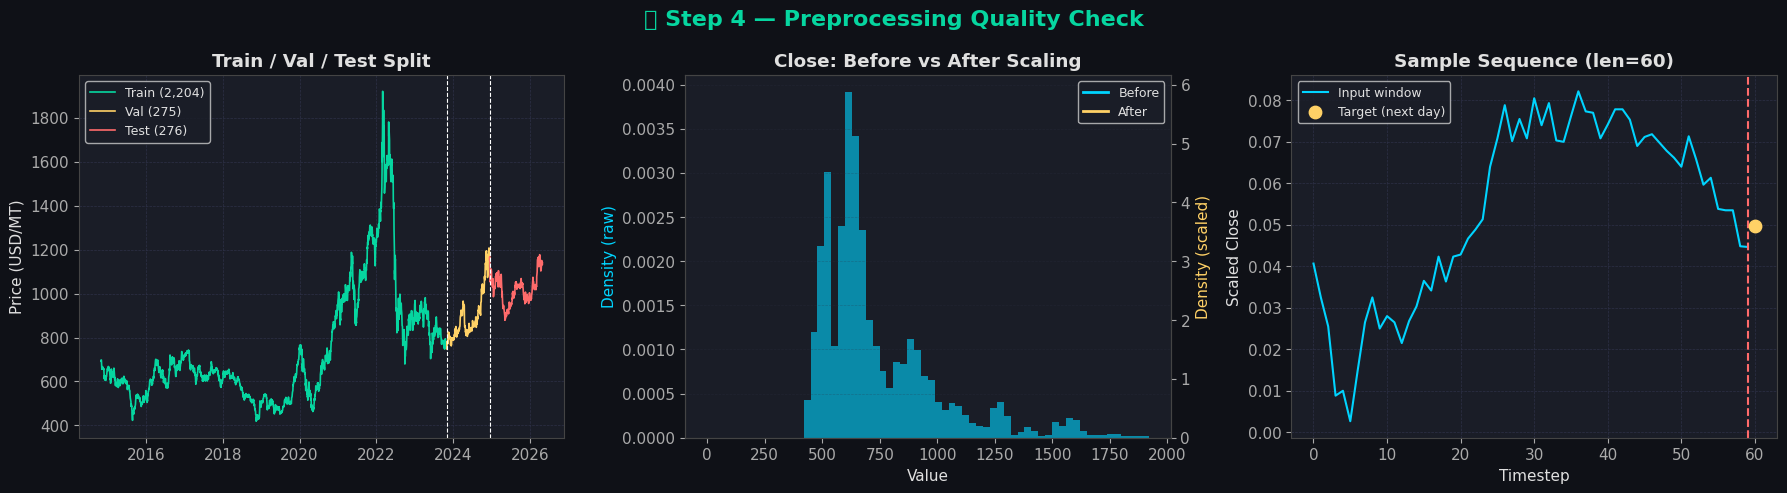

In [11]:
# ── Visualization 4: Preprocessing Quality Check ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🧹 Step 4 — Preprocessing Quality Check',
             fontsize=16, fontweight='bold', color=PALETTE['green'])

# Train/Val/Test split on Close price timeline
ax = axes[0]
dates_all = df['Date'].values
close_all  = df['Close'].values
ax.plot(dates_all[:train_end], close_all[:train_end],
        color=PALETTE['green'], lw=1.2, label=f'Train ({train_end:,})')
ax.plot(dates_all[train_end:val_end], close_all[train_end:val_end],
        color=PALETTE['accent'], lw=1.2, label=f'Val ({val_end-train_end:,})')
ax.plot(dates_all[val_end:], close_all[val_end:],
        color=PALETTE['secondary'], lw=1.2, label=f'Test ({n-val_end:,})')
ax.axvline(dates_all[train_end], color='white', ls='--', lw=0.8)
ax.axvline(dates_all[val_end], color='white', ls='--', lw=0.8)
ax.set_title('Train / Val / Test Split', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
ax.grid(True)

# Distribution before vs after scaling
ax = axes[1]
close_before = train_data[:, target_idx]
close_after  = train_scaled[:, target_idx]
ax.hist(close_before, bins=50, color=PALETTE['primary'], alpha=0.6,
        label='Before scaling', density=True)
ax2 = ax.twinx()
ax2.hist(close_after, bins=50, color=PALETTE['accent'], alpha=0.6,
         label='After scaling', density=True)
ax.set_title('Close: Before vs After Scaling', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density (raw)', color=PALETTE['primary'])
ax2.set_ylabel('Density (scaled)', color=PALETTE['accent'])
lines1 = [plt.Line2D([0], [0], color=PALETTE['primary'], lw=2),
           plt.Line2D([0], [0], color=PALETTE['accent'], lw=2)]
ax.legend(lines1, ['Before', 'After'], fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Sample sequence visualization
ax = axes[2]
sample_seq = X_train[200, :, target_idx]  # Sample window of Close feature
ax.plot(range(SEQ), sample_seq, color=PALETTE['primary'], lw=1.5, label='Input window')
ax.axvline(SEQ - 1, color=PALETTE['secondary'], ls='--', lw=1.5)
ax.scatter([SEQ], [y_train[200]], color=PALETTE['accent'], s=80, zorder=5, label='Target (next day)')
ax.set_title(f'Sample Sequence (len={SEQ})', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Scaled Close')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('step4_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 Step 5 — LSTM Model Architecture

In [12]:
class AttentionLayer(nn.Module):
    """Additive (Bahdanau-style) attention over LSTM hidden states."""
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out: torch.Tensor) -> torch.Tensor:
        # lstm_out: (batch, seq_len, hidden)
        scores  = self.attn(lstm_out)            # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)   # Attention weights
        context = (weights * lstm_out).sum(dim=1)  # Weighted sum → (batch, hidden)
        return context, weights


class CPO_LSTM(nn.Module):
    """
    Stacked LSTM with optional bidirectional mode and attention.
    Architecture: LSTM stack → Attention (optional) → FC head.
    """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int,
                 dropout: float, bidirectional: bool, use_attention: bool):
        super().__init__()
        self.use_attention  = use_attention
        self.bidirectional  = bidirectional
        self.hidden_size    = hidden_size
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0.0,
            batch_first  = True,
            bidirectional= bidirectional
        )

        lstm_out_size = hidden_size * self.num_directions

        self.attention = AttentionLayer(lstm_out_size) if use_attention else None

        # Fully-connected regression head
        self.fc = nn.Sequential(
            nn.LayerNorm(lstm_out_size),
            nn.Linear(lstm_out_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Linear(hidden_size // 4, 1)
        )

    def forward(self, x: torch.Tensor):
        lstm_out, _ = self.lstm(x)        # (batch, seq_len, hidden*dir)

        if self.use_attention:
            context, attn_weights = self.attention(lstm_out)
        else:
            context = lstm_out[:, -1, :]  # Last timestep
            attn_weights = None

        out = self.fc(context)
        return out, attn_weights


# ── Instantiate model ────────────────────────────────────────────────────────
INPUT_SIZE = X_train.shape[2]  # Number of features

model = CPO_LSTM(
    input_size   = INPUT_SIZE,
    hidden_size  = CONFIG['lstm_hidden_size'],
    num_layers   = CONFIG['lstm_num_layers'],
    dropout      = CONFIG['dropout_rate'],
    bidirectional= CONFIG['bidirectional'],
    use_attention= CONFIG['use_attention']
).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('🧠 Model Architecture:')
print(model)
print(f'\n   Total parameters   : {total_params:,}')
print(f'   Trainable params   : {trainable_params:,}')
print(f'   Input features     : {INPUT_SIZE}')
print(f'   Sequence length    : {SEQ}')
print(f'   Bidirectional LSTM : {CONFIG["bidirectional"]}')
print(f'   Attention mechanism: {CONFIG["use_attention"]}')

🧠 Model Architecture:
CPO_LSTM(
  (lstm): LSTM(29, 128, num_layers=3, batch_first=True, dropout=0.3)
  (attention): AttentionLayer(
    (attn): Linear(in_features=128, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

   Total parameters   : 356,354
   Trainable params   : 356,354
   Input features     : 29
   Sequence length    : 60
   Bidirectional LSTM : False
   Attention mechanism: True


---
## 🏋️ Step 6 — Model Training

In [13]:
# ── Loss function ────────────────────────────────────────────────────────────
loss_map = {
    'MSE'  : nn.MSELoss(),
    'MAE'  : nn.L1Loss(),
    'Huber': nn.HuberLoss(delta=0.5)
}
criterion = loss_map[CONFIG['loss_function']]

# ── Optimizer ────────────────────────────────────────────────────────────────
opt_map = {
    'Adam' : torch.optim.Adam,
    'AdamW': torch.optim.AdamW,
    'SGD'  : torch.optim.SGD
}
optimizer = opt_map[CONFIG['optimizer']](
    model.parameters(),
    lr           = CONFIG['learning_rate'],
    weight_decay = CONFIG['weight_decay']
)

# ── LR Scheduler ─────────────────────────────────────────────────────────────
if CONFIG['scheduler_type'] == 'StepLR':
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=CONFIG['lr_step_size'], gamma=CONFIG['lr_gamma'])
elif CONFIG['scheduler_type'] == 'ReduceLROnPlateau':
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=CONFIG['lr_gamma'],
        patience=CONFIG['lr_patience'], verbose=True)
else:  # CosineAnnealing
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['lr_t_max'])

print(f'✅ Optimizer : {CONFIG["optimizer"]} | LR: {CONFIG["learning_rate"]}')
print(f'✅ Loss      : {CONFIG["loss_function"]}')
print(f'✅ Scheduler : {CONFIG["scheduler_type"]}')

# ── Training Loop ────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience: int, min_delta: float):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

early_stop = EarlyStopping(CONFIG['patience'], CONFIG['min_delta'])

train_losses, val_losses, lr_history = [], [], []

print(f'\n🏋️ Training started | Epochs: {CONFIG["epochs"]} | '
      f'Batch: {CONFIG["batch_size"]} | Device: {DEVICE}')
print('─' * 65)

for epoch in range(1, CONFIG['epochs'] + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    batch_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        pred, _ = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip'])
        optimizer.step()
        batch_loss += loss.item()

    train_loss = batch_loss / len(train_loader)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            pred, _ = model(X_b)
            val_loss += criterion(pred, y_b).item()
    val_loss /= len(val_loader)

    # ── Scheduler step ───────────────────────────────────────────────────────
    if CONFIG['scheduler_type'] == 'ReduceLROnPlateau':
        scheduler.step(val_loss)
    else:
        scheduler.step()

    cur_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(cur_lr)

    # ── Logging ──────────────────────────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch [{epoch:>4}/{CONFIG["epochs"]}] '
              f'Train Loss: {train_loss:.6f} | '
              f'Val Loss: {val_loss:.6f} | LR: {cur_lr:.2e}')

    # ── Early Stopping ───────────────────────────────────────────────────────
    if CONFIG['early_stopping'] and early_stop(val_loss, model):
        print(f'\n⚡ Early stopping at epoch {epoch} '
              f'(best val loss: {early_stop.best_loss:.6f})')
        model.load_state_dict(early_stop.best_state)
        break

print('─' * 65)
print(f'✅ Training complete! Best Val Loss: {min(val_losses):.6f}')

if CONFIG['save_model']:
    torch.save({
        'model_state': model.state_dict(),
        'config'     : CONFIG,
        'feature_cols': feature_cols,
        'target_idx' : target_idx
    }, 'cpo_lstm_model.pth')
    print('💾 Model saved: cpo_lstm_model.pth')

✅ Optimizer : Adam | LR: 0.001
✅ Loss      : MSE
✅ Scheduler : CosineAnnealing

🏋️ Training started | Epochs: 100 | Batch: 32 | Device: cuda
─────────────────────────────────────────────────────────────────
  Epoch [   1/100] Train Loss: 0.012715 | Val Loss: 0.004514 | LR: 9.99e-04
  Epoch [  10/100] Train Loss: 0.002003 | Val Loss: 0.000760 | LR: 9.05e-04
  Epoch [  20/100] Train Loss: 0.001212 | Val Loss: 0.000682 | LR: 6.55e-04
  Epoch [  30/100] Train Loss: 0.000938 | Val Loss: 0.000830 | LR: 3.45e-04
  Epoch [  40/100] Train Loss: 0.000674 | Val Loss: 0.000630 | LR: 9.55e-05
  Epoch [  50/100] Train Loss: 0.000607 | Val Loss: 0.000617 | LR: 0.00e+00

⚡ Early stopping at epoch 56 (best val loss: 0.000579)
─────────────────────────────────────────────────────────────────
✅ Training complete! Best Val Loss: 0.000579
💾 Model saved: cpo_lstm_model.pth


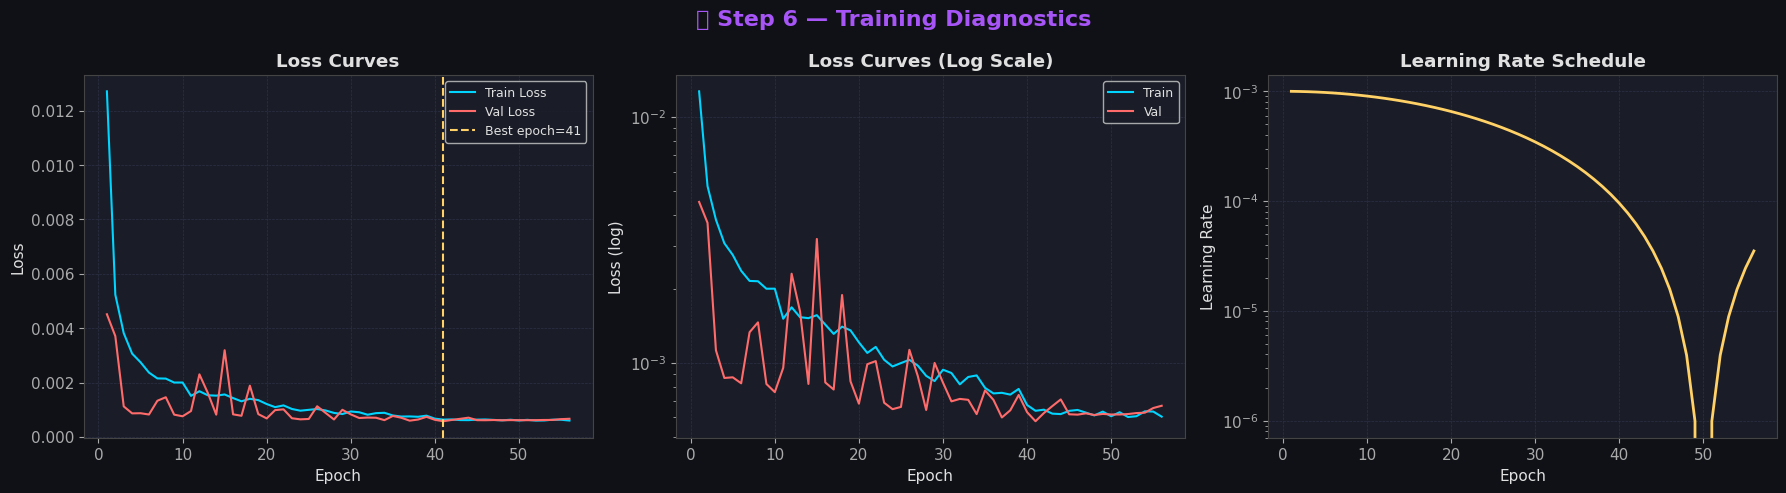

In [14]:
# ── Visualization 5: Training Diagnostics ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏋️ Step 6 — Training Diagnostics',
             fontsize=16, fontweight='bold', color=PALETTE['purple'])

epochs_ran = range(1, len(train_losses) + 1)

# Loss curves
ax = axes[0]
ax.plot(epochs_ran, train_losses, color=PALETTE['primary'], lw=1.5, label='Train Loss')
ax.plot(epochs_ran, val_losses, color=PALETTE['secondary'], lw=1.5, label='Val Loss')
best_ep = np.argmin(val_losses) + 1
ax.axvline(best_ep, color=PALETTE['accent'], ls='--', lw=1.5,
           label=f'Best epoch={best_ep}')
ax.set_title('Loss Curves', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=9)
ax.grid(True)

# Loss curves (log scale)
ax = axes[1]
ax.semilogy(epochs_ran, train_losses, color=PALETTE['primary'], lw=1.5, label='Train')
ax.semilogy(epochs_ran, val_losses, color=PALETTE['secondary'], lw=1.5, label='Val')
ax.set_title('Loss Curves (Log Scale)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log)')
ax.legend(fontsize=9)
ax.grid(True)

# LR Schedule
ax = axes[2]
ax.plot(epochs_ran, lr_history, color=PALETTE['accent'], lw=2)
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.grid(True)

plt.tight_layout()
plt.savefig('step6_training.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📈 Step 7 — Evaluation & Model Diagnostics

In [20]:
def predict_all(model, loader, scaler_close, device):
    """Run inference on a dataloader, inverse-transform predictions."""
    model.eval()
    preds_s, trues_s = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out, _ = model(X_b.to(device))
            preds_s.append(out.cpu().numpy())
            trues_s.append(y_b.numpy())
    preds_s = np.concatenate(preds_s)
    trues_s = np.concatenate(trues_s)

    # Inverse scale
    preds = scaler_close.inverse_transform(preds_s)
    trues = scaler_close.inverse_transform(trues_s)
    return preds.flatten(), trues.flatten()


def compute_metrics(y_true, y_pred, name: str):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2    = r2_score(y_true, y_pred)
    da    = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    print(f'\n📊 {name} Metrics:')
    print(f'   MAE   : {mae:.4f}  (Mean Absolute Error)')
    print(f'   RMSE  : {rmse:.4f}  (Root Mean Squared Error)')
    print(f'   MAPE  : {mape:.2f}% (Mean Absolute Percentage Error)')
    print(f'   R²    : {r2:.4f}  (Coefficient of Determination)')
    print(f'   DA    : {da:.2f}% (Directional Accuracy)')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'DA': da}


val_preds,  val_trues  = predict_all(model, val_loader,  close_scaler, DEVICE)
test_preds, test_trues = predict_all(model, test_loader, close_scaler, DEVICE)

val_metrics  = compute_metrics(val_trues,  val_preds,  'Validation')
test_metrics = compute_metrics(test_trues, test_preds, 'Test')

# Timestamps for test set
test_dates = df['Date'].iloc[val_end : val_end + len(test_preds)].values


📊 Validation Metrics:
   MAE   : 26.3243  (Mean Absolute Error)
   RMSE  : 34.5567  (Root Mean Squared Error)
   MAPE  : 2.89% (Mean Absolute Percentage Error)
   R²    : 0.9018  (Coefficient of Determination)
   DA    : 47.81% (Directional Accuracy)

📊 Test Metrics:
   MAE   : 50.6645  (Mean Absolute Error)
   RMSE  : 63.9187  (Root Mean Squared Error)
   MAPE  : 4.93% (Mean Absolute Percentage Error)
   R²    : 0.0539  (Coefficient of Determination)
   DA    : 48.36% (Directional Accuracy)


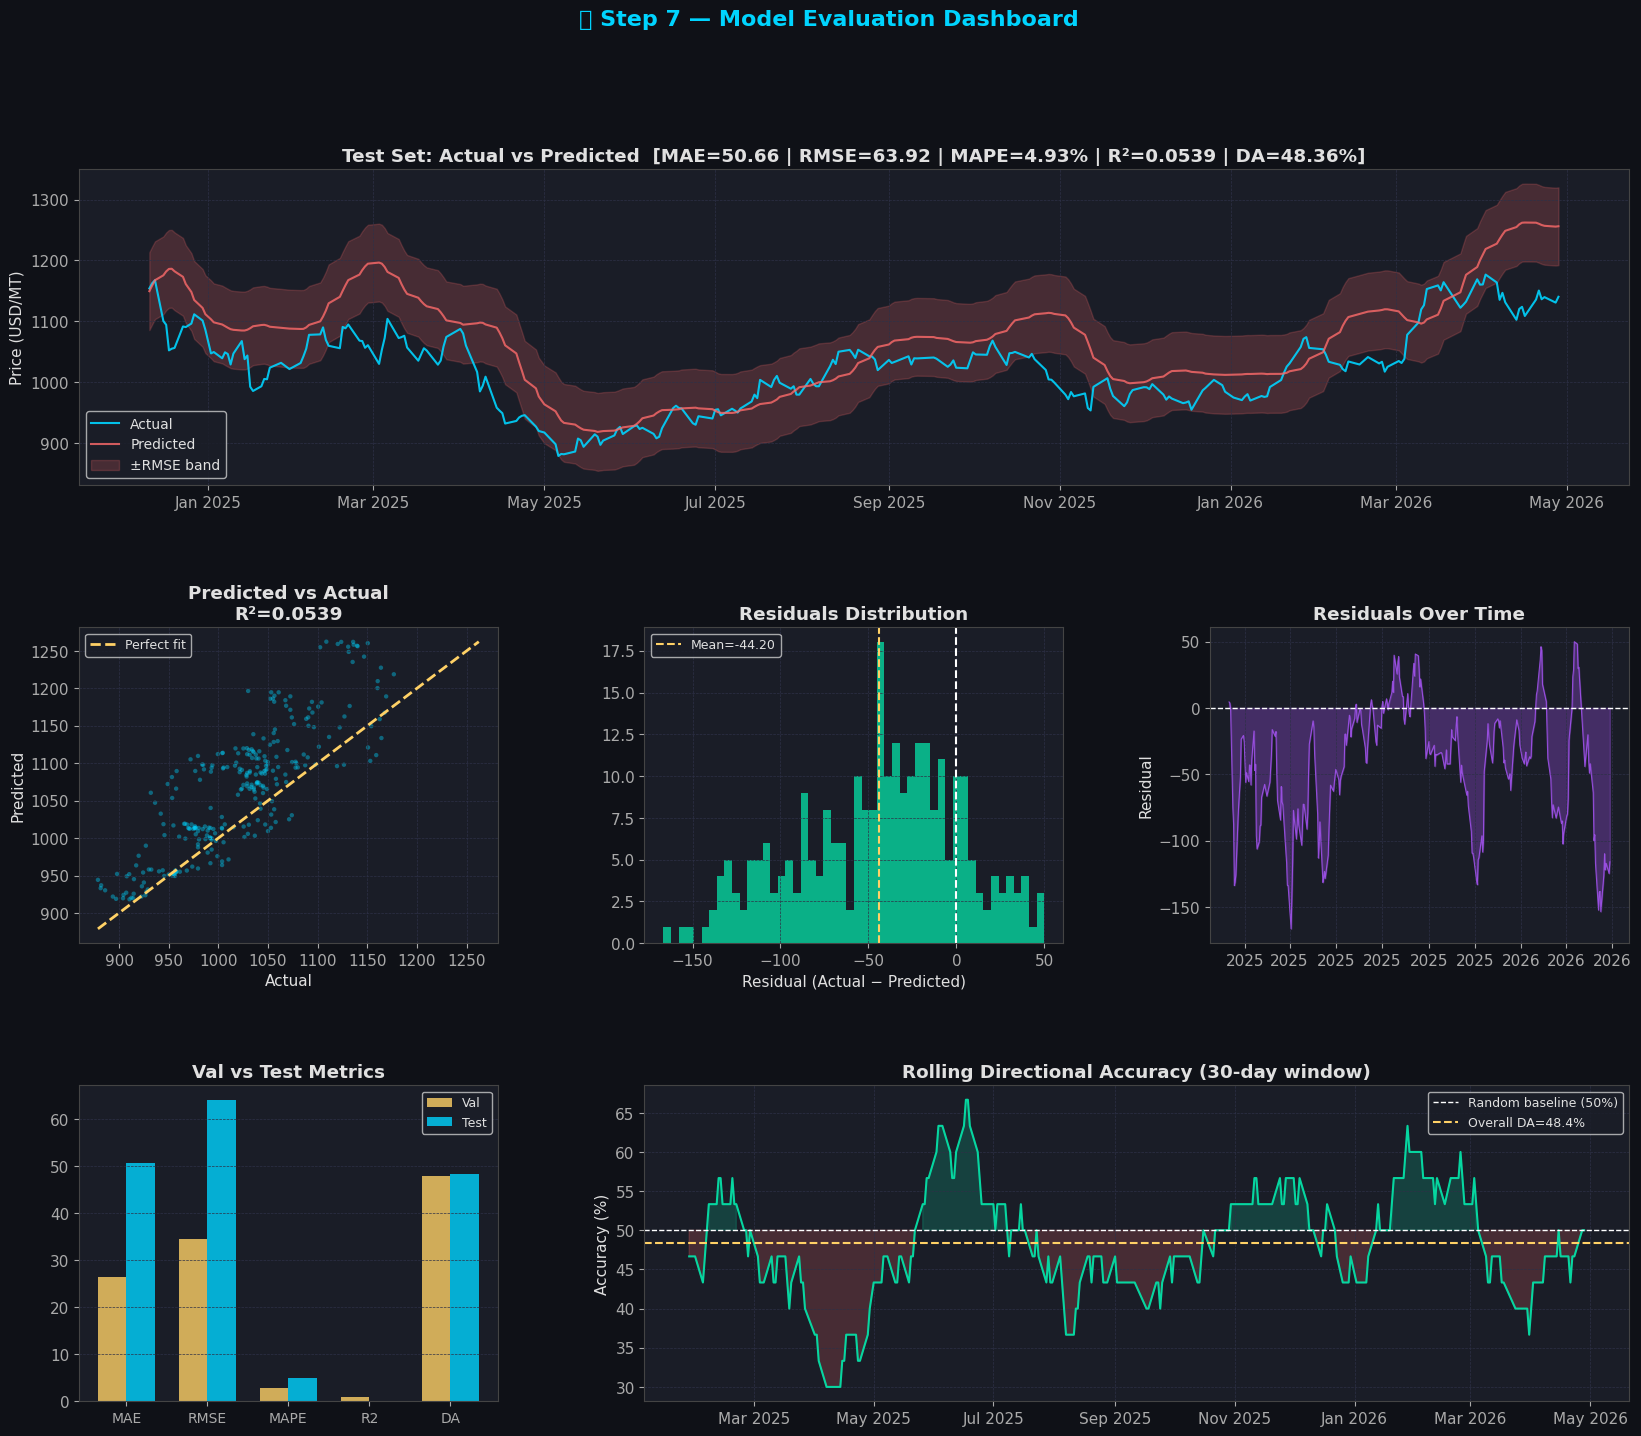

✅ Step 7 complete.


In [21]:
# ── Visualization 6: Evaluation Dashboard ────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('📈 Step 7 — Model Evaluation Dashboard',
             fontsize=16, fontweight='bold', color=PALETTE['primary'])

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# 7a. Test: Predicted vs Actual (full)
ax = fig.add_subplot(gs[0, :])
ax.plot(test_dates, test_trues, color=PALETTE['primary'], lw=1.5,
        alpha=0.9, label='Actual')
ax.plot(test_dates, test_preds, color=PALETTE['secondary'], lw=1.5,
        alpha=0.8, label='Predicted')
ax.fill_between(test_dates,
                test_preds - test_metrics['RMSE'],
                test_preds + test_metrics['RMSE'],
                alpha=0.2, color=PALETTE['secondary'], label='±RMSE band')
ax.set_title(f'Test Set: Actual vs Predicted  '
             f'[MAE={test_metrics["MAE"]:.2f} | RMSE={test_metrics["RMSE"]:.2f} | '
             f'MAPE={test_metrics["MAPE"]:.2f}% | R²={test_metrics["R2"]:.4f} | '
             f'DA={test_metrics["DA"]:.2f}%]', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=10)
ax.grid(True)

# 7b. Scatter: Predicted vs Actual
ax = fig.add_subplot(gs[1, 0])
ax.scatter(test_trues, test_preds, color=PALETTE['primary'],
           alpha=0.4, s=10, edgecolors='none')
mn, mx = min(test_trues.min(), test_preds.min()), max(test_trues.max(), test_preds.max())
ax.plot([mn, mx], [mn, mx], color=PALETTE['accent'], ls='--', lw=2, label='Perfect fit')
ax.set_title(f'Predicted vs Actual\nR²={test_metrics["R2"]:.4f}', fontweight='bold')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.legend(fontsize=9)
ax.grid(True)

# 7c. Residuals distribution
ax = fig.add_subplot(gs[1, 1])
residuals = test_trues - test_preds
ax.hist(residuals, bins=50, color=PALETTE['green'], alpha=0.8, edgecolor='none')
ax.axvline(0, color='white', ls='--', lw=1.5)
ax.axvline(residuals.mean(), color=PALETTE['accent'], ls='--', lw=1.5,
           label=f'Mean={residuals.mean():.2f}')
ax.set_title('Residuals Distribution', fontweight='bold')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.legend(fontsize=9)
ax.grid(True)

# 7d. Residuals over time
ax = fig.add_subplot(gs[1, 2])
ax.plot(test_dates, residuals, color=PALETTE['purple'], lw=0.8, alpha=0.8)
ax.axhline(0, color='white', ls='--', lw=1)
ax.fill_between(test_dates, residuals, alpha=0.3, color=PALETTE['purple'])
ax.set_title('Residuals Over Time', fontweight='bold')
ax.set_ylabel('Residual')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True)

# 7e. Metrics comparison bar chart
ax = fig.add_subplot(gs[2, 0])
metrics_names = ['MAE', 'RMSE', 'MAPE', 'R2', 'DA']
val_vals  = [val_metrics[m]  for m in metrics_names]
test_vals = [test_metrics[m] for m in metrics_names]
x = np.arange(len(metrics_names))
width = 0.35
ax.bar(x - width/2, val_vals,  width, label='Val',  color=PALETTE['accent'],  alpha=0.8)
ax.bar(x + width/2, test_vals, width, label='Test', color=PALETTE['primary'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.set_title('Val vs Test Metrics', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# 7f. Directional accuracy rolling
ax = fig.add_subplot(gs[2, 1:])
window = 30
da_rolling = pd.Series(
    (np.sign(np.diff(test_trues)) == np.sign(np.diff(test_preds))).astype(float)
).rolling(window).mean() * 100
ax.plot(test_dates[1:len(da_rolling)+1], da_rolling.values,
        color=PALETTE['green'], lw=1.5)
ax.axhline(50, color='white', ls='--', lw=1, label='Random baseline (50%)')
ax.axhline(test_metrics['DA'], color=PALETTE['accent'], ls='--', lw=1.5,
           label=f'Overall DA={test_metrics["DA"]:.1f}%')
ax.fill_between(test_dates[1:len(da_rolling)+1], 50, da_rolling.values,
                where=da_rolling.values > 50, alpha=0.2, color=PALETTE['green'])
ax.fill_between(test_dates[1:len(da_rolling)+1], 50, da_rolling.values,
                where=da_rolling.values <= 50, alpha=0.2, color=PALETTE['secondary'])
ax.set_title(f'Rolling Directional Accuracy ({window}-day window)', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9)
ax.grid(True)

plt.savefig('step7_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Step 7 complete.')

---
## 🔮 Step 8 — 7-Day Price Forecast

In [22]:
def forecast_n_days(
    model: nn.Module,
    last_window: np.ndarray,    # Shape: (seq_len, n_features) — already scaled
    n_days: int,
    close_scaler,
    all_scaler,
    target_idx: int,
    device: torch.device,
    n_mc_samples: int = 50     # Monte Carlo dropout for uncertainty
) -> dict:
    """
    Autoregressive forecast: each predicted Close feeds back as input
    for the next timestep. Uses MC Dropout for confidence intervals.

    Returns:
        dict with 'mean', 'lower_90', 'upper_90', 'lower_50', 'upper_50'
    """
    model.train()  # Keep dropout active for MC sampling

    all_samples = []
    for _ in range(n_mc_samples):
        window = last_window.copy()  # (seq_len, n_features)
        preds_scaled = []
        for _ in range(n_days):
            x_t = torch.tensor(window[np.newaxis, :, :],
                               dtype=torch.float32).to(device)
            with torch.no_grad():
                pred_s, _ = model(x_t)
            pred_val = pred_s.item()
            preds_scaled.append(pred_val)

            # Roll window: drop oldest, append new row with updated Close
            new_row = window[-1].copy()
            new_row[target_idx] = pred_val
            window = np.vstack([window[1:], new_row])

        preds_scaled = np.array(preds_scaled).reshape(-1, 1)
        preds_price  = close_scaler.inverse_transform(preds_scaled).flatten()
        all_samples.append(preds_price)

    model.eval()

    all_samples = np.array(all_samples)  # (n_mc, n_days)
    return {
        'mean'     : all_samples.mean(axis=0),
        'std'      : all_samples.std(axis=0),
        'lower_90' : np.percentile(all_samples, 5,  axis=0),
        'upper_90' : np.percentile(all_samples, 95, axis=0),
        'lower_50' : np.percentile(all_samples, 25, axis=0),
        'upper_50' : np.percentile(all_samples, 75, axis=0),
        'all'      : all_samples
    }


# ── Prepare last window (latest seq_len days from full scaled data) ───────────
full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled], axis=0)
last_window = full_scaled[-SEQ:]   # Most recent window

HORIZON = CONFIG['forecast_horizon']  # 7 days

forecast = forecast_n_days(
    model        = model,
    last_window  = last_window,
    n_days       = HORIZON,
    close_scaler = close_scaler,
    all_scaler   = scaler,
    target_idx   = target_idx,
    device       = DEVICE,
    n_mc_samples = 100
)

# Generate business day forecast dates
last_date    = df['Date'].max()
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON)

# Forecast table
forecast_df = pd.DataFrame({
    'Date'       : future_dates,
    'Day'        : [d.strftime('%A') for d in future_dates],
    'Pred_Mean'  : forecast['mean'].round(2),
    'Lower_50'   : forecast['lower_50'].round(2),
    'Upper_50'   : forecast['upper_50'].round(2),
    'Lower_90'   : forecast['lower_90'].round(2),
    'Upper_90'   : forecast['upper_90'].round(2),
    'Uncertainty': forecast['std'].round(4)
})

last_close = df['Close'].iloc[-1]
forecast_df['Change_vs_Today'] = (forecast_df['Pred_Mean'] - last_close).round(2)
forecast_df['Change_Pct']      = ((forecast_df['Pred_Mean'] - last_close) / last_close * 100).round(2)

print(f'\n🔮 7-DAY CPO PRICE FORECAST')
print(f'   Last known Close : ${last_close:.2f} ({df["Date"].max().date()})')
print(f'   Forecast method  : Autoregressive LSTM + MC Dropout (100 samples)')
print()
display(forecast_df.set_index('Date'))
print('✅ Step 8 — Forecast generated.')


🔮 7-DAY CPO PRICE FORECAST
   Last known Close : $1140.25 (2026-04-28)
   Forecast method  : Autoregressive LSTM + MC Dropout (100 samples)



,Day,Pred_Mean,Lower_50,Upper_50,Lower_90,Upper_90,Uncertainty,Change_vs_Today,Change_Pct
Date,,,,,,,,,
2026-04-29,Wednesday,1262.25,1234.68,1287.72,1198.51,1330.97,42.2697,122.00,10.70
2026-04-30,Thursday,1253.53,1231.24,1280.96,1191.19,1301.61,33.8478,113.28,9.93
2026-05-01,Friday,1254.62,1227.39,1284.19,1186.07,1320.59,40.5020,114.37,10.03
2026-05-04,Monday,1250.77,1225.19,1280.24,1175.28,1309.27,41.9833,110.52,9.69
2026-05-05,Tuesday,1252.12,1225.93,1277.13,1191.36,1305.38,36.8578,111.87,9.81
2026-05-06,Wednesday,1247.29,1226.70,1275.03,1182.20,1300.57,38.6236,107.04,9.39
2026-05-07,Thursday,1249.29,1222.95,1273.40,1182.01,1309.77,39.1387,109.04,9.56


✅ Step 8 — Forecast generated.


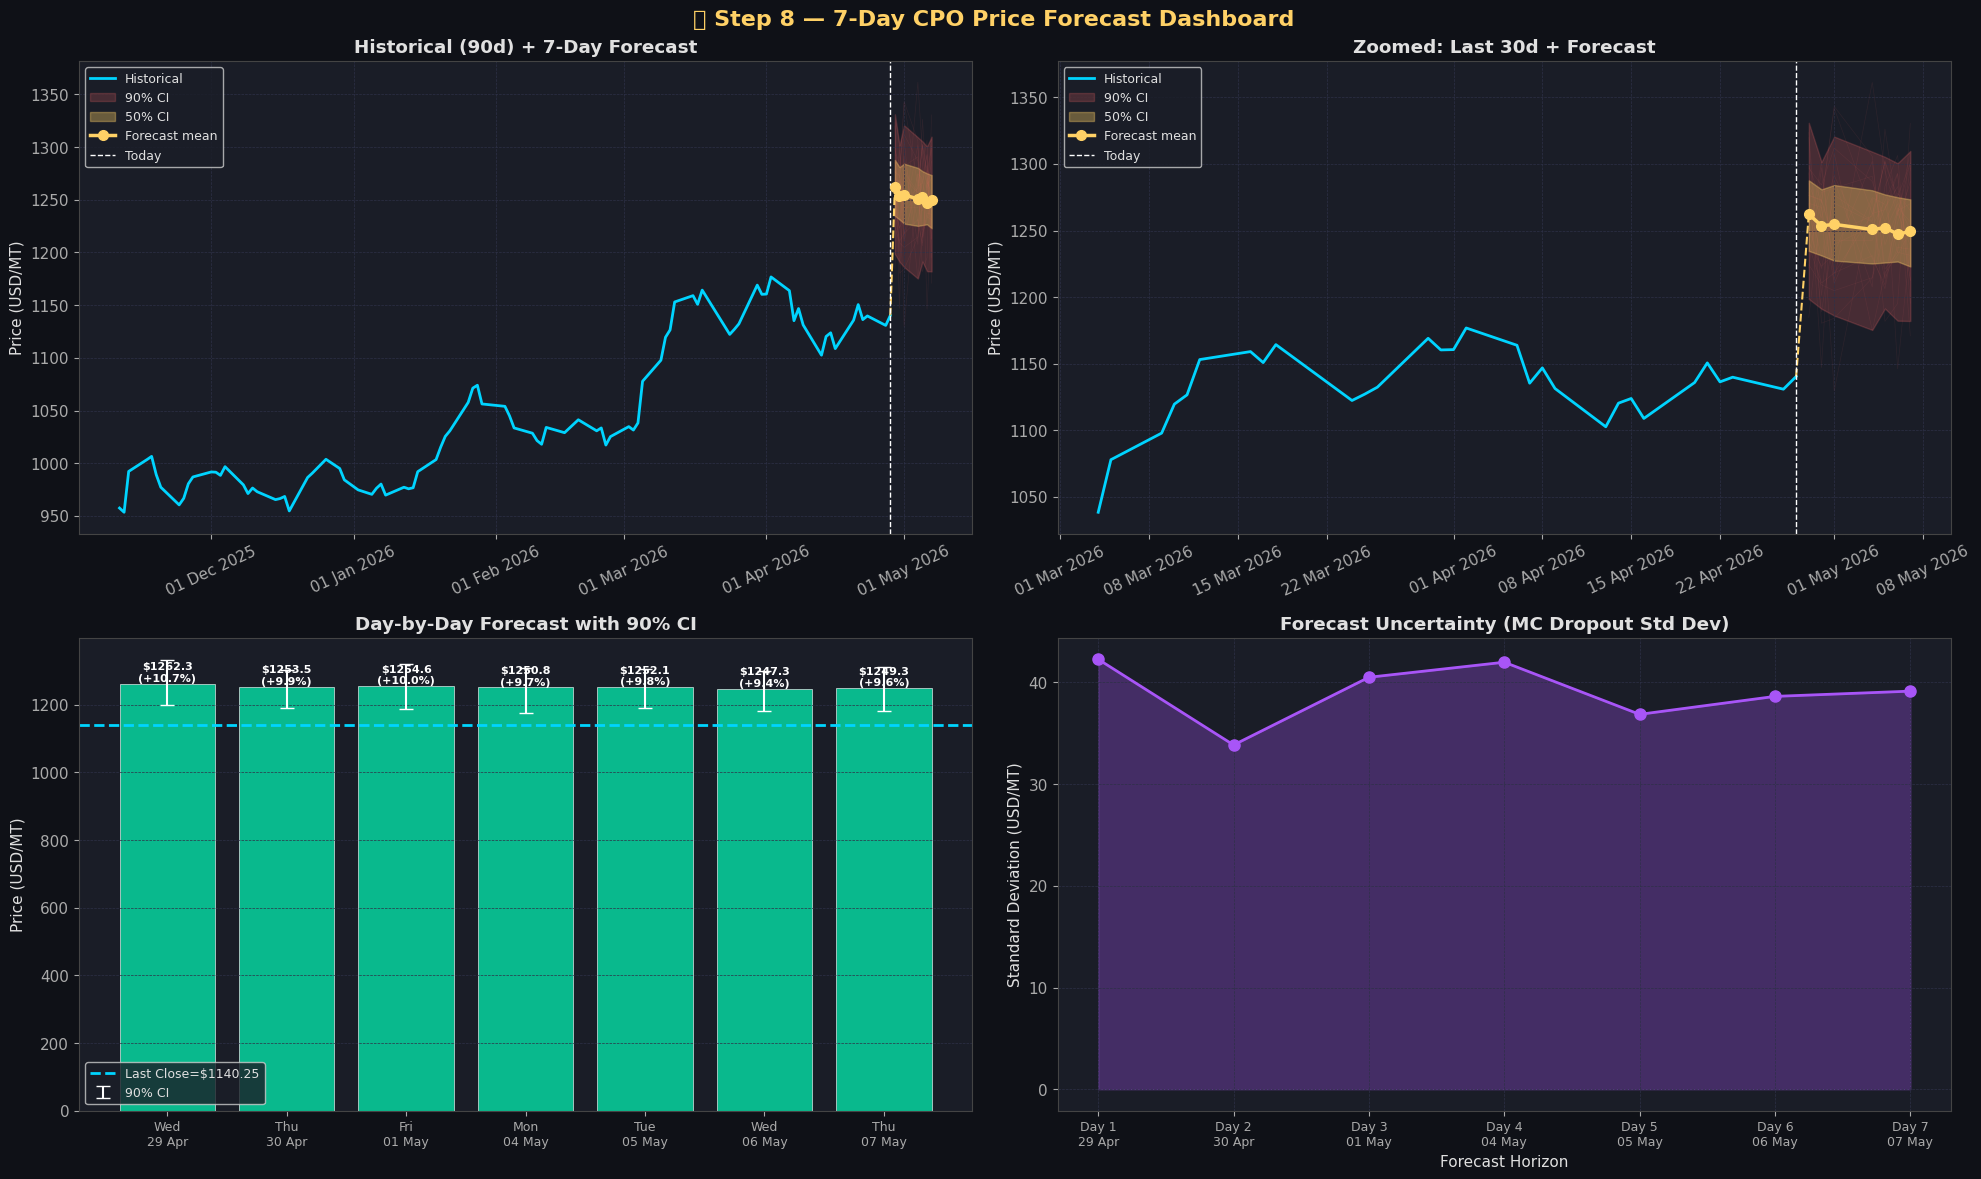

In [23]:
# ── Visualization 7: Forecast Dashboard ──────────────────────────────────────
context_days = 90
hist_dates   = df['Date'].values[-context_days:]
hist_close   = df['Close'].values[-context_days:]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('🔮 Step 8 — 7-Day CPO Price Forecast Dashboard',
             fontsize=16, fontweight='bold', color=PALETTE['accent'])

# 8a. Main forecast chart
ax = axes[0, 0]
ax2 = axes[0, 1]

for axi, (sl, title) in enumerate([
    (slice(None), f'Historical ({context_days}d) + 7-Day Forecast'),
    (slice(-30, None), 'Zoomed: Last 30d + Forecast')
]):
    ax = axes[0, axi]
    hdates = hist_dates[sl]
    hclose = hist_close[sl]

    ax.plot(hdates, hclose, color=PALETTE['primary'], lw=2, label='Historical')

    # MC samples (faint)
    for samp in forecast['all'][::5]:
        ax.plot(future_dates, samp, color=PALETTE['secondary'],
                lw=0.5, alpha=0.08)

    # CI bands
    ax.fill_between(future_dates, forecast['lower_90'], forecast['upper_90'],
                    alpha=0.2, color=PALETTE['secondary'], label='90% CI')
    ax.fill_between(future_dates, forecast['lower_50'], forecast['upper_50'],
                    alpha=0.35, color=PALETTE['accent'], label='50% CI')
    ax.plot(future_dates, forecast['mean'], 'o-',
            color=PALETTE['accent'], lw=2.5, markersize=7, label='Forecast mean', zorder=5)

    # Connect last historical to first forecast
    ax.plot([hist_dates[-1], future_dates[0]],
            [hist_close[-1], forecast['mean'][0]],
            color=PALETTE['accent'], ls='--', lw=1.5)

    ax.axvline(hist_dates[-1], color='white', ls='--', lw=1, label='Today')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Price (USD/MT)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True)

# 8b. Day-by-day forecast bar with error bars
ax = axes[1, 0]
colors = [PALETTE['green'] if v >= last_close else PALETTE['secondary']
          for v in forecast['mean']]
bars = ax.bar(range(HORIZON), forecast['mean'], color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.errorbar(range(HORIZON),
            forecast['mean'],
            yerr=[forecast['mean'] - forecast['lower_90'],
                  forecast['upper_90'] - forecast['mean']],
            fmt='none', color='white', capsize=5, lw=1.5, label='90% CI')
ax.axhline(last_close, color=PALETTE['primary'], ls='--', lw=2,
           label=f'Last Close=${last_close:.2f}')
ax.set_xticks(range(HORIZON))
ax.set_xticklabels([d.strftime('%a\n%d %b') for d in future_dates], fontsize=9)
ax.set_title('Day-by-Day Forecast with 90% CI', fontweight='bold')
ax.set_ylabel('Price (USD/MT)')

for i, (bar, val) in enumerate(zip(bars, forecast['mean'])):
    pct = forecast_df['Change_Pct'].iloc[i]
    sign = '+' if pct >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${val:.1f}\n({sign}{pct:.1f}%)',
            ha='center', va='bottom', fontsize=8, color='white', fontweight='bold')

ax.legend(fontsize=9)
ax.grid(True, axis='y')

# 8c. Uncertainty evolution
ax = axes[1, 1]
ax.plot(range(1, HORIZON+1), forecast['std'], 'o-',
        color=PALETTE['purple'], lw=2, markersize=8)
ax.fill_between(range(1, HORIZON+1), 0, forecast['std'],
                alpha=0.3, color=PALETTE['purple'])
ax.set_xticks(range(1, HORIZON+1))
ax.set_xticklabels([f'Day {i}\n{d.strftime("%d %b")}'
                    for i, d in enumerate(future_dates, 1)], fontsize=9)
ax.set_title('Forecast Uncertainty (MC Dropout Std Dev)', fontweight='bold')
ax.set_ylabel('Standard Deviation (USD/MT)')
ax.set_xlabel('Forecast Horizon')
ax.grid(True)

plt.tight_layout()
plt.savefig('step8_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 Step 9 — Summary Report

In [24]:
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║              🌴 CPO LSTM FORECASTING — FINAL SUMMARY               ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

print(f'\n📊 DATASET')
print(f'   Rows             : {len(df):,}')
print(f'   Date Range       : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'   Features Used    : {INPUT_SIZE}')
print(f'   Sequence Length  : {SEQ} days')

print(f'\n🧠 MODEL')
print(f'   Architecture     : Stacked LSTM ({CONFIG["lstm_num_layers"]} layers × {CONFIG["lstm_hidden_size"]} hidden)')
print(f'   Bidirectional    : {CONFIG["bidirectional"]}')
print(f'   Attention        : {CONFIG["use_attention"]}')
print(f'   Total Parameters : {trainable_params:,}')
print(f'   Dropout          : {CONFIG["dropout_rate"]}')
print(f'   Optimizer        : {CONFIG["optimizer"]} (lr={CONFIG["learning_rate"]})')
print(f'   Loss Function    : {CONFIG["loss_function"]}')
print(f'   Epochs Trained   : {len(train_losses)}')

print(f'\n📈 TEST SET PERFORMANCE')
for k, v in test_metrics.items():
    unit = '%' if k in ('MAPE', 'DA') else ''
    print(f'   {k:<8}: {v:.4f}{unit}')

print(f'\n🔮 7-DAY FORECAST SUMMARY')
print(f'   Last known price : ${last_close:.2f}')
print(f'   Day 7 prediction : ${forecast["mean"][-1]:.2f} '
      f'({forecast_df["Change_Pct"].iloc[-1]:+.2f}%)')
print()
for _, row in forecast_df.iterrows():
    trend = '📈' if row['Change_Pct'] >= 0 else '📉'
    print(f'   {trend} {row["Date"].strftime("%a %d %b")}  '
          f'${row["Pred_Mean"]:.2f}  [{row["Lower_90"]:.2f}–{row["Upper_90"]:.2f}]  '
          f'({row["Change_Pct"]:+.2f}%)')

print(f'\n⚠️  DISCLAIMER')
print('   Prediksi ini bersifat kuantitatif berdasarkan pola historis.')
print('   Faktor eksternal (kebijakan ekspor, cuaca, geopolitik) TIDAK')
print('   tercakup dalam model. Gunakan sebagai referensi, bukan keputusan tunggal.')
print('═' * 72)

# Download outputs
if CONFIG['save_model']:
    print('\n💾 Downloading model and plots...')
    for f_name in ['cpo_lstm_model.pth', 'step8_forecast.png', 'step7_evaluation.png']:
        try:
            files.download(f_name)
        except:
            print(f'   ⚠️ Could not auto-download {f_name} (normal in script mode)')

╔══════════════════════════════════════════════════════════════════════╗
║              🌴 CPO LSTM FORECASTING — FINAL SUMMARY               ║
╚══════════════════════════════════════════════════════════════════════╝

📊 DATASET
   Rows             : 2,755
   Date Range       : 2014-10-30 → 2026-04-28
   Features Used    : 29
   Sequence Length  : 60 days

🧠 MODEL
   Architecture     : Stacked LSTM (3 layers × 128 hidden)
   Bidirectional    : False
   Attention        : True
   Total Parameters : 356,354
   Dropout          : 0.3
   Optimizer        : Adam (lr=0.001)
   Loss Function    : MSE
   Epochs Trained   : 56

📈 TEST SET PERFORMANCE
   MAE     : 50.6645
   RMSE    : 63.9187
   MAPE    : 4.9258%
   R2      : 0.0539
   DA      : 48.3636%

🔮 7-DAY FORECAST SUMMARY
   Last known price : $1140.25
   Day 7 prediction : $1249.29 (+9.56%)

   📈 Wed 29 Apr  $1262.25  [1198.51–1330.97]  (+10.70%)
   📈 Thu 30 Apr  $1253.53  [1191.19–1301.61]  (+9.93%)
   📈 Fri 01 May  $1254.62  [1186.07–13

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>